# MuRIL Model

In [2]:
! pip install "datasets==2.20.0" --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 547.8/547.8 kB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.1/316.1 kB 41.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.5.0 which is incompatible.


In [3]:
# MuRIL (Multilingual Representations for Indian Languages)n

import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from pathlib import Path
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay
)

In [4]:
!git clone https://github.com/vardhman18/HinSafe.git /content/HINSAFE

Cloning into '/content/HINSAFE'...
remote: Enumerating objects: 16777, done.
remote: Counting objects: 100% (23/23), done.
remote: Compressing objects: 100% (21/21), done.
remote: Total 16777 (delta 0), reused 17 (delta 0), pack-reused 16754 (from 1)
Receiving objects: 100% (16777/16777), 162.59 MiB | 14.36 MiB/s, done.
Resolving deltas: 100% (1577/1577), done.
Updating files: 100% (14778/14778), done.


In [5]:
from pathlib import Path
import sys

PROJECT_ROOT = Path("/content/HINSAFE")
sys.path.insert(0, str(PROJECT_ROOT))

print("Project exists:", PROJECT_ROOT.exists())
print("src exists:", (PROJECT_ROOT / "src").exists())

Project exists: True
src exists: True


In [6]:
from src.preprocessing import basic_clean
from src.evaluate import evaluate_model

In [7]:
pd.set_option("display.max_colwidth", 100)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [8]:
# GPU check

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU device:", torch.cuda.get_device_name(0))
    DEVICE = torch.device("cuda")
else:
    print("WARNING: GPU is not available.")
    print("Enable GPU in your Colab runtime before training.")

    DEVICE = torch.device("cpu")

print("Selected device:", DEVICE)

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU device: Tesla T4
Selected device: cuda


In [9]:
# File paths

TRAIN_PATH = PROJECT_ROOT / "datasets" / "processed" / "train_split.csv"
VAL_PATH = PROJECT_ROOT / "datasets" / "processed" / "val_split.csv"
TEST_PATH = PROJECT_ROOT / "datasets" / "processed" / "test_split.csv"

MODEL_SAVE_DIR = PROJECT_ROOT / "saved_models" / "mbert"

RESULTS_PATH = PROJECT_ROOT / "results" / "model_comparison.csv"
CONFUSION_MATRIX_PATH = PROJECT_ROOT / "results" / "confusion_matrices" / "mbert.png"

MODEL_SAVE_DIR.mkdir(parents=True, exist_ok=True)
(PROJECT_ROOT / "saved_models").mkdir(exist_ok=True)
(PROJECT_ROOT / "results" / "confusion_matrices").mkdir(parents=True, exist_ok=True)

print("Train file exists:", TRAIN_PATH.exists())
print("Validation file exists:", VAL_PATH.exists())
print("Test file exists:", TEST_PATH.exists())


Train file exists: True
Validation file exists: True
Test file exists: True


In [10]:
# Model settings 

MODEL_NAME = "google/muril-base-cased"
MAX_LENGTH = 128          # Hinglish comments are short — 128 tokens is enough
BATCH_SIZE = 16          
NUM_EPOCHS = 3
LEARNING_RATE = 2e-5


print("Model:", MODEL_NAME)
print("Maximum sequence length:", MAX_LENGTH)
print("Batch size:", BATCH_SIZE)
print("Epochs:", NUM_EPOCHS)
print("Learning rate:", LEARNING_RATE)

Model: google/muril-base-cased
Maximum sequence length: 128
Batch size: 16
Epochs: 3
Learning rate: 2e-05


In [11]:

# Load datasets

try:
    train_df = pd.read_csv(TRAIN_PATH)
    val_df = pd.read_csv(VAL_PATH)
    test_df = pd.read_csv(TEST_PATH)

    print("Datasets loaded successfully!\n")

    print("Training set:", train_df.shape)
    print("Validation set:", val_df.shape)
    print("Test set:", test_df.shape)

except FileNotFoundError as e:
    print("Error: Could not find one of the dataset files.")
    print("Please check the file paths.")
    print(e)

Datasets loaded successfully!

Training set: (4288, 2)
Validation set: (920, 2)
Test set: (920, 2)


In [12]:
required_columns = ["text", "label"]

for name, df in [
    ("Training", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:
    missing_columns = [
        col for col in required_columns
        if col not in df.columns
    ]

    if missing_columns:
        print(f"{name} set is missing: {missing_columns}")
    else:
        print(f"{name} set: OK")

print("\nExample training data:")
display(train_df[["text", "label"]].head())

Training set: OK
Validation set: OK
Test set: OK

Example training data:


,text,label
0,mama ke dabre se bahir a gaye ho kya baat ha chote bacha ka rape howa tha qasoor me baad me pata...,1
1,chinta kt kro beta madhur tmko tmri bhakti ke lie rajya sabha mn entry mil jaegi bo bhi rape ke ...,0
2,modi ka to pata nahi par aj vi delhi me rape ro raha hai tum log sirf modi modi modi ka mala jap...,0
3,teri gaand ka business,1
4,aur hum par terrorism ka label lagane wale duniya ache tarah jante hai aur tu bhe india is the m...,1


In [14]:
# convert pandas DataFrames to Hugging Face Datasets

train_dataset = Dataset.from_pandas(train_df[["text", "label"]])
val_dataset = Dataset.from_pandas(val_df[["text", "label"]])
test_dataset = Dataset.from_pandas(test_df[["text", "label"]])

print(train_dataset)

Dataset({
    features: ['text', 'label'],
    num_rows: 4288
})


In [15]:
# Load mURIL Tokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer loaded successfully.")
print("Tokenizer vocabulary size:", tokenizer.vocab_size)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/206 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/3.16M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/113 [00:00<?, ?B/s]

Tokenizer loaded successfully.
Tokenizer vocabulary size: 197258


In [16]:

def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH
    )

In [17]:
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/4288 [00:00<?, ? examples/s]

Map:   0%|          | 0/920 [00:00<?, ? examples/s]

Map:   0%|          | 0/920 [00:00<?, ? examples/s]

In [18]:
columns_to_keep = ["input_ids", "attention_mask", "label"]

train_dataset = train_dataset.remove_columns(
    [col for col in train_dataset.column_names if col not in columns_to_keep]
)
val_dataset = val_dataset.remove_columns(
    [col for col in val_dataset.column_names if col not in columns_to_keep]
)
test_dataset = test_dataset.remove_columns(
    [col for col in test_dataset.column_names if col not in columns_to_keep]
)

In [19]:
# Inspect one tokenized example
print("Original text:", train_df["text"].iloc[0])
print("Token IDs:", train_dataset[0]["input_ids"][:20])

Original text: mama ke dabre se bahir a gaye ho kya baat ha chote bacha ka rape howa tha qasoor me baad me pata chala ke tum b un ke sath the ye ha hidmat
Token IDs: [104, 16320, 2110, 1159, 5159, 50004, 1257, 160122, 7269, 172, 5087, 1926, 7616, 4873, 9656, 34087, 38624, 8343, 25124, 25084]


In [ ]:
# Load mURIL model with a classification head

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2   # offensive / not offensive
)

print(f"{MODEL_NAME} loaded with a classification head")

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  953MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: google/muril-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params w

google/muril-base-cased loaded with a classification head


model.safetensors: reconstructing file:   0%|          |  0.00B /  953MB            

model.safetensors: downloading bytes:           |  0.00B            

In [21]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1_score(labels, predictions, average="weighted"),
        "precision": precision_score(labels, predictions, average="weighted"),
        "recall": recall_score(labels, predictions, average="weighted"),
    }

In [25]:
# Training Arguments

CHECKPOINT_DIR = MODEL_SAVE_DIR / "checkpoints"
TRAINING_LOG_DIR = MODEL_SAVE_DIR / "logs"

os.environ["TENSORBOARD_LOGGING_DIR"] = str(TRAINING_LOG_DIR)

training_args = TrainingArguments(
    output_dir=str(CHECKPOINT_DIR),
    
    # Evaluation
    eval_strategy="epoch",
    save_strategy="epoch",
    
    # Batch sizes
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,

    # Training
    num_train_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE,
    weight_decay=0.01,

    # Select best checkpoint
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    
    # Logging
    logging_steps=50,
    
    # Do not automatically send data to external logging services
    report_to="none",

    # Reproducibility
    seed=42,
    
    # Prevent unnecessary external integrations
    push_to_hub=False
)

print("Training arguments set:")

Training arguments set:


In [26]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

print("Starting training...")
trainer.train()
print("Training complete")

Starting training...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.602520,0.617395,0.681522,0.672492,0.677550,0.681522
2,0.529661,0.531597,0.761957,0.743390,0.794468,0.761957
3,0.503259,0.524526,0.759783,0.746919,0.774625,0.759783


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training complete


In [27]:
val_output = trainer.evaluate(val_dataset)
print("Validation results:")
for key, value in val_output.items():
    print(f"  {key}: {value}")

Training Loss,Validation Loss,Epoch,Accuracy,F1,Precision,Recall
0.503259,0.524526,3,0.759783,0.746919,0.774625,0.759783


Validation results:
  eval_loss: 0.52452552318573
  eval_accuracy: 0.7597826086956522
  eval_f1: 0.746919127225439
  eval_precision: 0.7746253010244321
  eval_recall: 0.7597826086956522


In [33]:
# Sample predictions 

def predict_single(
    text,
    model,
    tokenizer,
    max_length=MAX_LENGTH
):
    """Predict one comment using the same device as the model."""

    device = next(model.parameters()).device

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=max_length
    )

    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }

    model.eval()

    with torch.no_grad():
        outputs = model(**inputs)
        probabilities = torch.softmax(
            outputs.logits,
            dim=1)[0]

    predicted_label = torch.argmax(probabilities).item()
    confidence = probabilities[predicted_label].item()

    return predicted_label, confidence


In [38]:
sample_comments = [
    "mar ja tu ",
    "thank you so much bhai",
    "kal milte hain, take care",
    "tu bekaar nahi hai"
]

cleaned_samples = [
    basic_clean(comment)
    for comment in sample_comments
]

for comment in cleaned_samples:
    label, confidence = predict_single(comment, model, tokenizer)
    label_text = "OFFENSIVE" if label == 1 else "NOT OFFENSIVE"
    print(f"{label_text:15s} | Confidence: {confidence:.4f} | {comment}")

OFFENSIVE       | Confidence: 0.7872 | mar ja tu
NOT OFFENSIVE   | Confidence: 0.7892 | thank you so much bhai
NOT OFFENSIVE   | Confidence: 0.7940 | kal milte hain take care
NOT OFFENSIVE   | Confidence: 0.7934 | tu bekaar nahi hai


In [39]:
model.save_pretrained(MODEL_SAVE_DIR)
tokenizer.save_pretrained(MODEL_SAVE_DIR)

print(f"Model and tokenizer saved to: {MODEL_SAVE_DIR}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved to: /content/HINSAFE/saved_models/mbert


In [41]:
# Test set evaluation

test_predictions_output = trainer.predict(test_dataset)
test_logits = test_predictions_output.predictions
test_predictions = np.argmax(test_logits, axis=1)
y_test = test_df["label"].values

test_results = evaluate_model(
    y_true=y_test,
    y_pred=test_predictions,
    model_name="MuRIL - Test"
)

print("Test set evaluation results:")

Test set evaluation results:


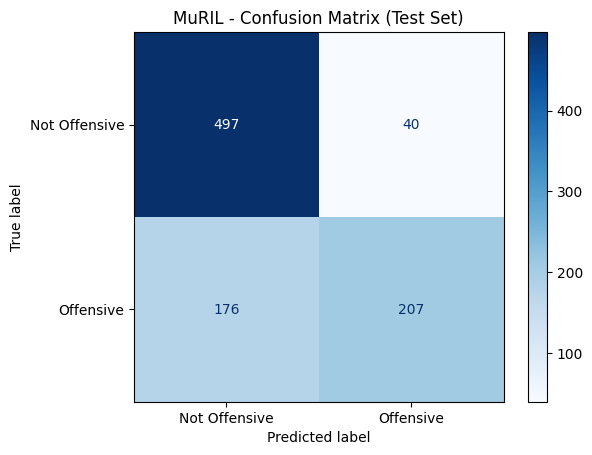

Confusion matrix saved to: /content/HINSAFE/results/confusion_matrices/mbert.png


In [42]:
cm = confusion_matrix(y_test, test_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Offensive", "Offensive"]
)

disp.plot(cmap="Blues")
plt.title("MuRIL - Confusion Matrix (Test Set)")
plt.savefig(CONFUSION_MATRIX_PATH, bbox_inches="tight")
plt.show()

print(f"Confusion matrix saved to: {CONFUSION_MATRIX_PATH}")

In [43]:
# Save muril test results

def log_result(results_dict, results_path):
    results_row = pd.DataFrame([results_dict])

    if os.path.exists(results_path):
        existing_results = pd.read_csv(results_path)
        updated_results = pd.concat(
            [existing_results, results_row],
            ignore_index=True
        )
        
    else:
        updated_results = results_row

    # Save updated results
    updated_results.to_csv(
        results_path,
        index=False
    )
    print(f"Results saved to: {results_path}")

log_result(
    test_results,
    RESULTS_PATH
)

Results saved to: /content/HINSAFE/results/model_comparison.csv


In [44]:
if os.path.exists(RESULTS_PATH):
    results_df = pd.read_csv(RESULTS_PATH)
    display(results_df)

else:
    print("No comparison results file found.")

,model,accuracy,precision,recall,f1
0,Naive Bayes - Test,0.713043,0.856287,0.373368,0.520000
1,Logistic Regression - Test,0.751087,0.823529,0.511749,0.631240
2,Linear SVM - Test,0.744565,0.750000,0.579634,0.653903
3,Linear SVM - Test,0.744565,0.750000,0.579634,0.653903
4,Logistic Regression - Test,0.751087,0.823529,0.511749,0.631240
5,Linear SVM - Test,0.744565,0.750000,0.579634,0.653903
6,BiLSTM - Test,0.765217,0.881279,0.503916,0.641196
7,mBERT - Test,0.770652,0.909524,0.498695,0.644182
8,mBERT - Test,0.775000,0.903670,0.514360,0.655574
9,MuRIL - Test,0.765217,0.838057,0.540470,0.657143


In [50]:
# Compare mBERT and MuRIL results

comparison_df = pd.read_csv(RESULTS_PATH)

print("Available columns:")
print(comparison_df.columns.tolist())

mbert_row = comparison_df[
    comparison_df["model"].astype(str).str.contains(
        "mBERT - Test",
        na=False
    )
]

muril_row = comparison_df[
    comparison_df["model"].astype(str).str.contains(
        "MuRIL - Test",
        na=False
    )
]

print("mBERT Test Results:")
print(mbert_row)

print("\nMuRIL Test Results:")
print(muril_row)


Available columns:
['model', 'accuracy', 'precision', 'recall', 'f1']
mBERT Test Results:
          model  accuracy  precision    recall        f1
7  mBERT - Test  0.770652   0.909524  0.498695  0.644182
8  mBERT - Test  0.775000   0.903670  0.514360  0.655574

MuRIL Test Results:
          model  accuracy  precision   recall        f1
9  MuRIL - Test  0.765217   0.838057  0.54047  0.657143


In [52]:
# Calculate F1-score improvement

if not mbert_row.empty and not muril_row.empty:
    mbert_f1 = float(mbert_row["f1"].iloc[0])
    muril_f1 = float(muril_row["f1"].iloc[0])

    improvement = (muril_f1 - mbert_f1) * 100

    print(f"\nmBERT F1: {mbert_f1:.4f}")
    print(f"MuRIL F1: {muril_f1:.4f}")
    print(
        f"MuRIL F1 difference: "
        f"{improvement:+.2f} percentage points"
    )

    if muril_f1 > mbert_f1:
        print("MuRIL has higher F1 than mBERT.")
    elif muril_f1 < mbert_f1:
        print("mBERT has higher F1 than MuRIL.")
    else:
        print("Both models have equal F1.")

else:
    print(
        "\nCould not compare the models. "
        "Check that both test results exist."
    )


mBERT F1: 0.6442
MuRIL F1: 0.6571
MuRIL F1 difference: +1.30 percentage points
MuRIL has higher F1 than mBERT.
